# 1 · Gaussian random fields and the linear density field

From a linear matter power spectrum to a sampled density contrast $\delta(\mathbf{x})$ on a periodic box,
and back: the measured $P(k)$, $\sigma(R)$ and one-point PDF recover the input theory.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from cobox import Box, GRFSampler, IsoModeMask, Particles, Window, ScalarField, stats
from colcdm import LPT, LinearMatterPowSpec, Cosmology

N, L = 64, 250.0                     # 64^3 cells, 250 Mpc/h
box = Box(N, L, 3)
cosmo = Cosmology.from_preset("planck18")
pk = LinearMatterPowSpec(transfer_kind="symbolic_pofk", growth_kind="symbolic_pofk", cosmology=cosmo)
bins = stats.KBins.log(box, 20)
k_th = jnp.logspace(-2.2, 0.1, 200)

/home/prosello/Documents/phd/code/cobox-repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Linear theory

`colcdm` provides a differentiable linear $P(k, a)$ (symbolic_pofk emulator) and growth factor $D(a)$.

sigma_8 = 0.822


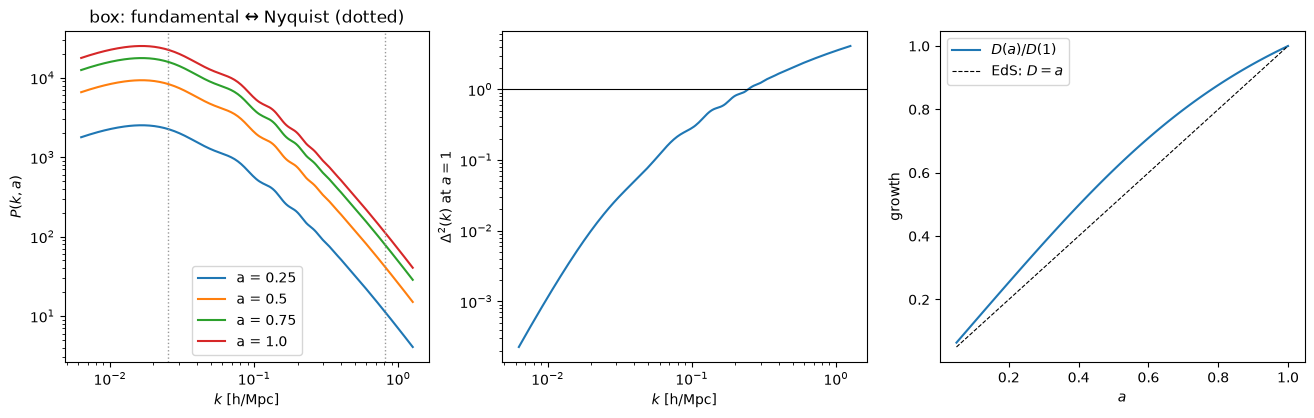

In [2]:
a_grid = jnp.linspace(0.05, 1.0, 100)
fig, axs = plt.subplots(1, 3, figsize=(16, 4.3))

for a in (0.25, 0.5, 0.75, 1.0):
    axs[0].loglog(k_th, pk(k_th, a=a), label=f"a = {a}")
axs[0].axvline(box.K_RES, color="0.6", ls=":", lw=1)
axs[0].axvline(box.K_NYQ, color="0.6", ls=":", lw=1)
axs[0].set(xlabel="$k$ [h/Mpc]", ylabel="$P(k, a)$", title="box: fundamental ↔ Nyquist (dotted)")
axs[0].legend()

axs[1].loglog(k_th, pk.delta_sq(k_th))
axs[1].axhline(1, color="k", lw=0.8)
axs[1].set(xlabel="$k$ [h/Mpc]", ylabel="$\\Delta^2(k)$ at $a=1$")

D = pk.linear_growth(a_grid) / pk.linear_growth(1.0)
axs[2].plot(a_grid, D, label="$D(a)/D(1)$")
axs[2].plot(a_grid, a_grid, "k--", lw=0.8, label="EdS: $D = a$")
axs[2].set(xlabel="$a$", ylabel="growth")
axs[2].legend()
print(f"sigma_8 = {float(pk.sigma8()):.3f}")

## Sampling

`GRFSampler(kind="real")` colours real-space white noise with $\sqrt{P(k)}$. The white noise is the latent
variable: the same seed gives the same structures for any cosmology.

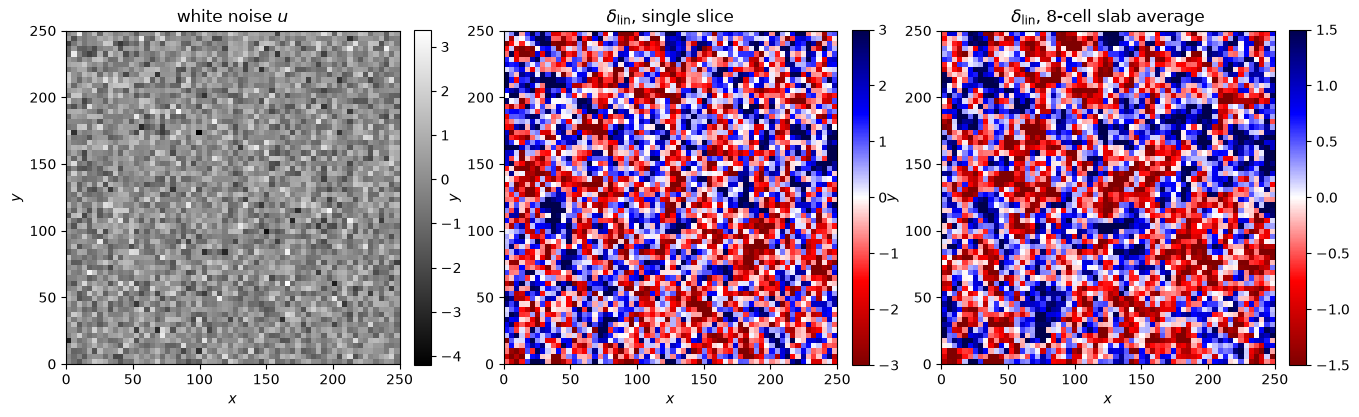

In [3]:
grf = GRFSampler(kind="real")
u = grf.get_randoms(seed=0, box=box)
delta = grf.sample(u, box, pk)                       # Fourier-space ScalarField at a = 1
white = ScalarField(u["u"].reshape(box.SHAPE), box)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
white.paint(ax=axs[0], cmap="gray", title="white noise $u$")
delta.paint(ax=axs[1], cmap="seismic_r", vmin=-3, vmax=3, title="$\\delta_{\\rm lin}$, single slice")
delta.paint(ax=axs[2], cmap="seismic_r", vmin=-1.5, vmax=1.5, width=8,
            title="$\\delta_{\\rm lin}$, 8-cell slab average");

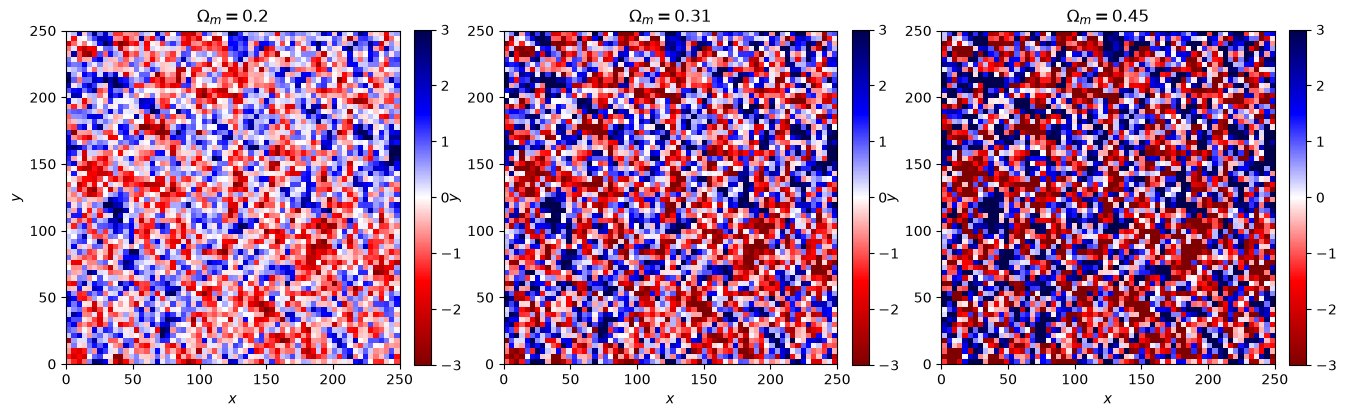

In [4]:
# Same latent noise, different cosmologies
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, Om in zip(axs, (0.20, 0.31, 0.45)):
    c = Cosmology.from_preset("planck18", Omega_cdm=Om - 0.049)
    grf.sample(u, box, lambda k: pk(k, cosmology=c)).paint(
        ax=ax, cmap="seismic_r", vmin=-3, vmax=3, title=f"$\\Omega_m = {Om}$")

## Recovering the input spectrum

Averaging over seeds, the measured $P(k)$ matches theory, and the seed-to-seed scatter matches the
Gaussian (cosmic variance) prediction $P\sqrt{2/N_{\rm modes}}$.

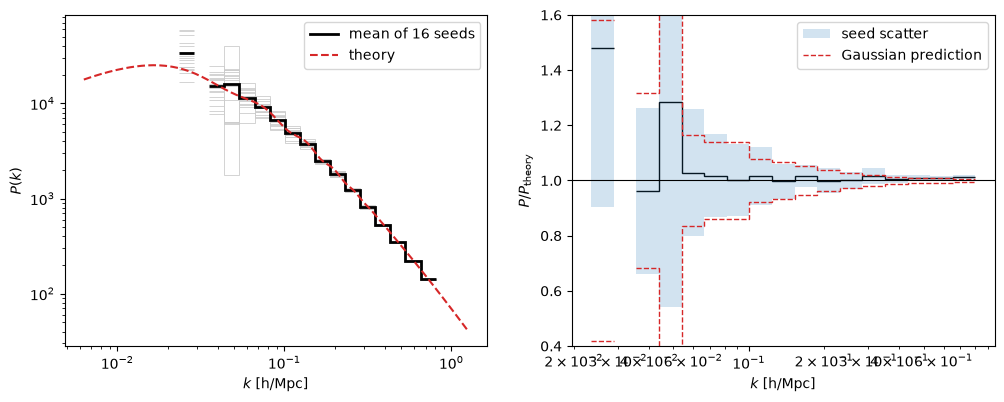

In [5]:
ps_list = [stats.power_spectrum(grf.sample_from_seed(s, box, pk), bins=bins) for s in range(16)]
ps = stats.stack(ps_list)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
for p in ps_list:
    p.plot(ax=axs[0], color="0.8", lw=0.6)
ps.plot(ax=axs[0], color="k", lw=2, label=f"mean of {ps.n_real} seeds")
axs[0].plot(k_th, pk(k_th), "C3--", label="theory")
axs[0].set(xlabel="$k$ [h/Mpc]", ylabel="$P(k)$")
axs[0].legend()

ratio = ps.ratio(pk)
err = ps.scatter / pk(ps.k_eff)
ps.plot(ax=axs[1], ratio_to=pk, color="k")
axs[1].stairs(ratio + err, ps.edges, baseline=ratio - err, fill=True, alpha=0.2, label="seed scatter")
g = ps_list[0].gaussian_error / pk(ps.k_eff)
axs[1].stairs(1 + g, ps.edges, baseline=None, color="C3", ls="--", label="Gaussian prediction")
axs[1].stairs(1 - g, ps.edges, baseline=None, color="C3", ls="--")
axs[1].axhline(1, color="k", lw=0.8)
axs[1].set(xlabel="$k$ [h/Mpc]", ylabel="$P / P_{\\rm theory}$", ylim=(0.4, 1.6))
axs[1].legend();

## Fourier-space sampling and mode masks

The `complex` sampler draws only the independent Fourier degrees of freedom, so modes can be switched off
exactly: here everything above $k = 0.1\,h/{\rm Mpc}$ is removed, leaving only the large-scale modes.

free real DOF: 137058 vs 250 with k < 0.1


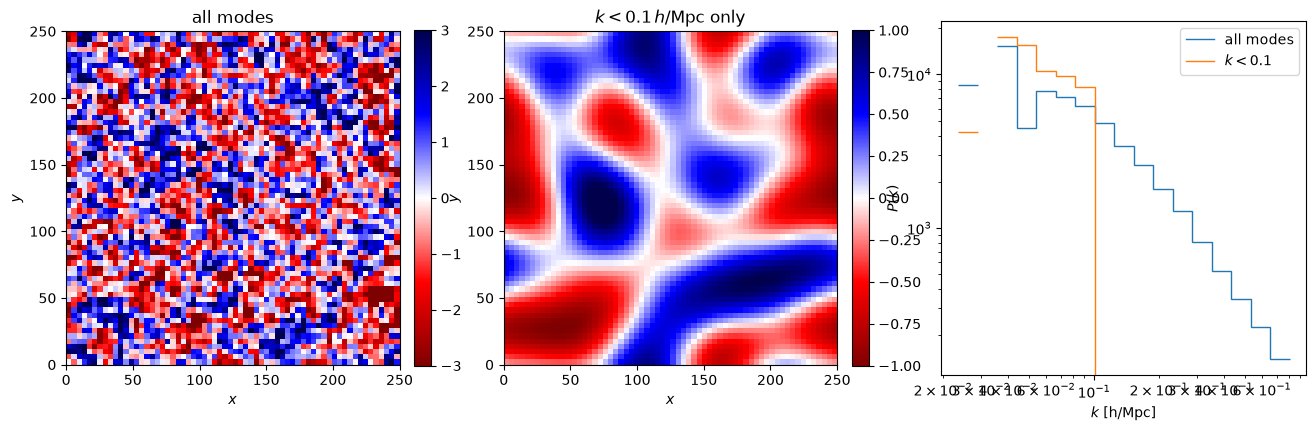

In [6]:
full = GRFSampler(kind="complex", complex_base="cartesian", restrictions=IsoModeMask("nyquist_open"))
large = GRFSampler(kind="complex", complex_base="cartesian",
                   restrictions=IsoModeMask("custom", k_range=(None, 0.1)))
print("free real DOF:", full.get_n_dof(box)["u"], "vs", large.get_n_dof(box)["u"], "with k < 0.1")

d_full, d_large = full.sample_from_seed(1, box, pk), large.sample_from_seed(1, box, pk)
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
d_full.paint(ax=axs[0], cmap="seismic_r", vmin=-3, vmax=3, title="all modes")
d_large.paint(ax=axs[1], cmap="seismic_r", vmin=-1, vmax=1, title="$k < 0.1\\,h$/Mpc only")
stats.power_spectrum(d_full, bins=bins).plot(ax=axs[2], label="all modes")
stats.power_spectrum(d_large, bins=bins).plot(ax=axs[2], label="$k < 0.1$")
axs[2].set(xlabel="$k$ [h/Mpc]", ylabel="$P(k)$")
axs[2].legend();

## Smoothing, $\sigma(R)$ and the one-point PDF

Convolving with a spherical top-hat of radius $R$ and measuring the variance recovers $\sigma(R)$;
the PDF of the linear field is Gaussian.

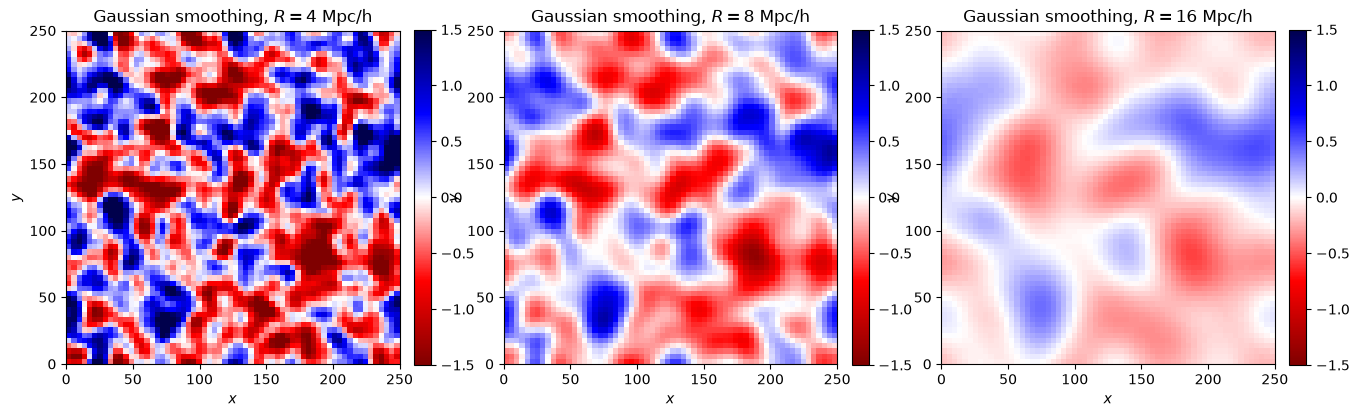

In [7]:
R_list = [4.0, 8.0, 16.0]
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, R in zip(axs, R_list):
    delta.convolve(Window("gaussian", 2 * R, normalized=True)).paint(
        ax=ax, cmap="seismic_r", vmin=-1.5, vmax=1.5, title=f"Gaussian smoothing, $R = {R:g}$ Mpc/h")

/tmp/ipykernel_17513/2637387273.py:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  Window("radial_tophat", 2 * R, normalized=True))).std) for R in R_meas] for s in range(8)])
/tmp/ipykernel_17513/2637387273.py:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  Window("radial_tophat", 2 * R, normalized=True))).std) for R in R_meas] for s in range(8)])
/tmp/ipykernel_17513/2637387273.py:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  Window("radial_tophat", 2 * R, normalized=True))).std) for R in R_meas] for s in range(8)])
/tmp/ipykernel_17513/2637387273.py:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  Window("radial_tophat", 2 * R, normalized=True))).std) for R in R_meas] for s in ran

Moments
  mean     = +1.397e-09
  std      = +0.8062
  var      = +0.65
  skewness = -0.0151
  kurtosis = -0.1574
  S3       = -0.01872
  S4       = -0.2421


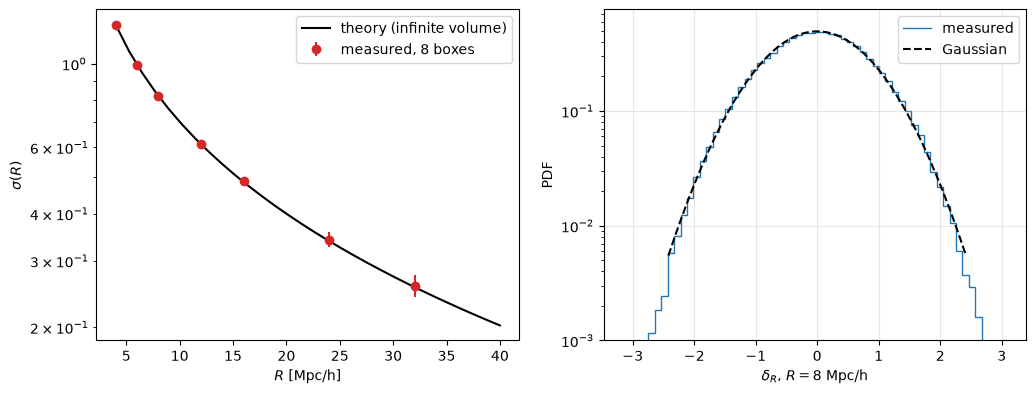

In [8]:
R_grid = jnp.linspace(4.0, 40.0, 30)
R_meas = jnp.array([4.0, 6.0, 8.0, 12.0, 16.0, 24.0, 32.0])
sig = np.array([[float(stats.moments(grf.sample_from_seed(s, box, pk).convolve(
    Window("radial_tophat", 2 * R, normalized=True))).std) for R in R_meas] for s in range(8)])

fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
axs[0].plot(R_grid, pk.sigma_R(R_grid), "k-", label="theory (infinite volume)")
axs[0].errorbar(R_meas, sig.mean(0), sig.std(0), fmt="o", color="C3", label="measured, 8 boxes")
axs[0].set(xlabel="$R$ [Mpc/h]", ylabel="$\\sigma(R)$", yscale="log")
axs[0].legend()

d8 = delta.convolve(Window("radial_tophat", 16.0, normalized=True))
m = stats.moments(d8)
x = jnp.linspace(-3, 3, 200) * m.std
stats.pdf(d8, n_bins=60, density=True).plot(ax=axs[1], label="measured")
axs[1].plot(x, jnp.exp(-0.5 * (x / m.std) ** 2) / (jnp.sqrt(2 * jnp.pi) * m.std), "k--", label="Gaussian")
axs[1].set(xlabel="$\\delta_R$, $R = 8$ Mpc/h", yscale="log", ylim=(1e-3, None))
axs[1].legend()
print(m)

Note: the measured $\sigma(R)$ sits slightly below theory at large $R$, since the box lacks modes with
$k < 2\pi/L$ (finite-volume effect).